In [2]:
!pip install kaggle

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers, models

In [4]:
import tensorflow_datasets as tfds

dataset, info = tfds.load('cats_vs_dogs', with_info=True, as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.4XYAN4_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [5]:
(train_ds_raw, test_ds_raw), info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

print(info)

tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings (Conference){asirra-a-captcha-that-exploits-interest-aligned-manual-image-categorization,
    author = {Elson, Jeremy and Douceur, Jo

In [6]:
class_names = ['cat', 'dog']
print(class_names)

['cat', 'dog']


In [7]:
IMG_SIZE = 32
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [8]:
train_ds = train_ds_raw.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds_raw.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

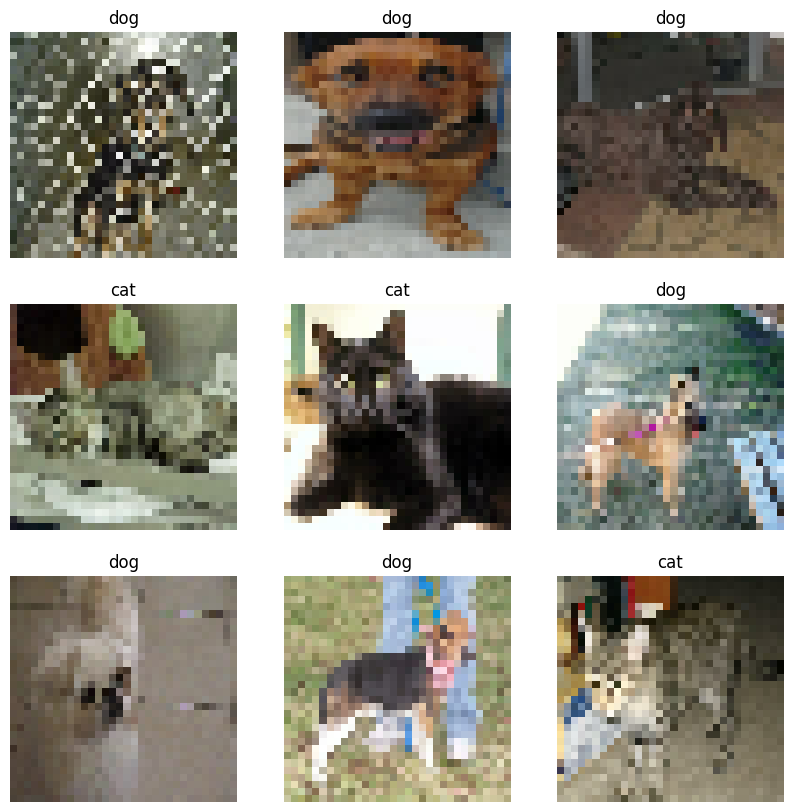

In [9]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[int(labels[i].numpy())])
        plt.axis("off")

plt.show()

In [10]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,985 (476.50 KB)

 Trainable params: 121,985 (476.50 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    train_ds,
    epochs=5,
    validation_data=test_ds
)

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 62s 96ms/step - accuracy: 0.6448 - loss: 0.6212 - val_accuracy: 0.7068 - val_loss: 0.5657
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 53s 87ms/step - accuracy: 0.7390 - loss: 0.5234 - val_accuracy: 0.7616 - val_loss: 0.5065
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 53s 89ms/step - accuracy: 0.7790 - loss: 0.4689 - val_accuracy: 0.7552 - val_loss: 0.5048
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 52s 87ms/step - accuracy: 0.7978 - loss: 0.4319 - val_accuracy: 0.7835 - val_loss: 0.4639
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 52s 88ms/step - accuracy: 0.8185 - loss: 0.3986 - val_accuracy: 0.7784 - val_loss: 0.4823


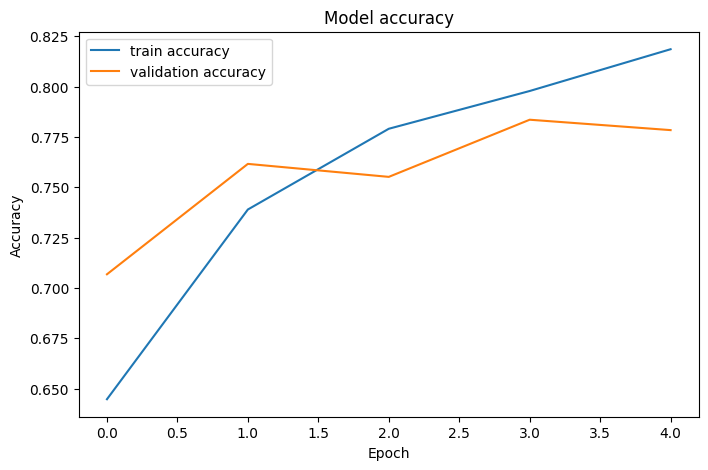

In [14]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model accuracy')
plt.show()

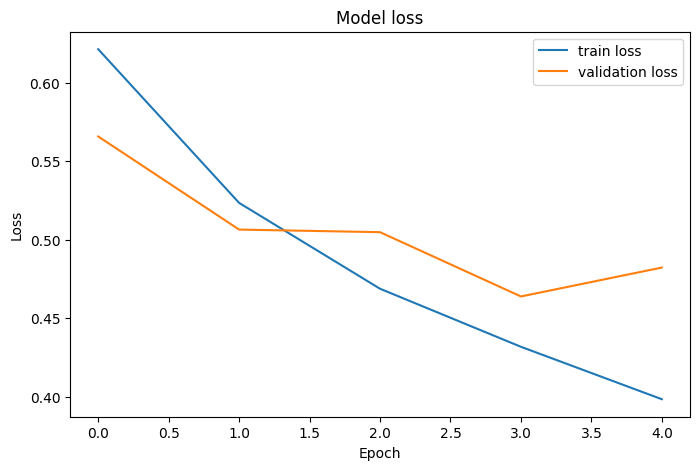

In [15]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Model loss')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


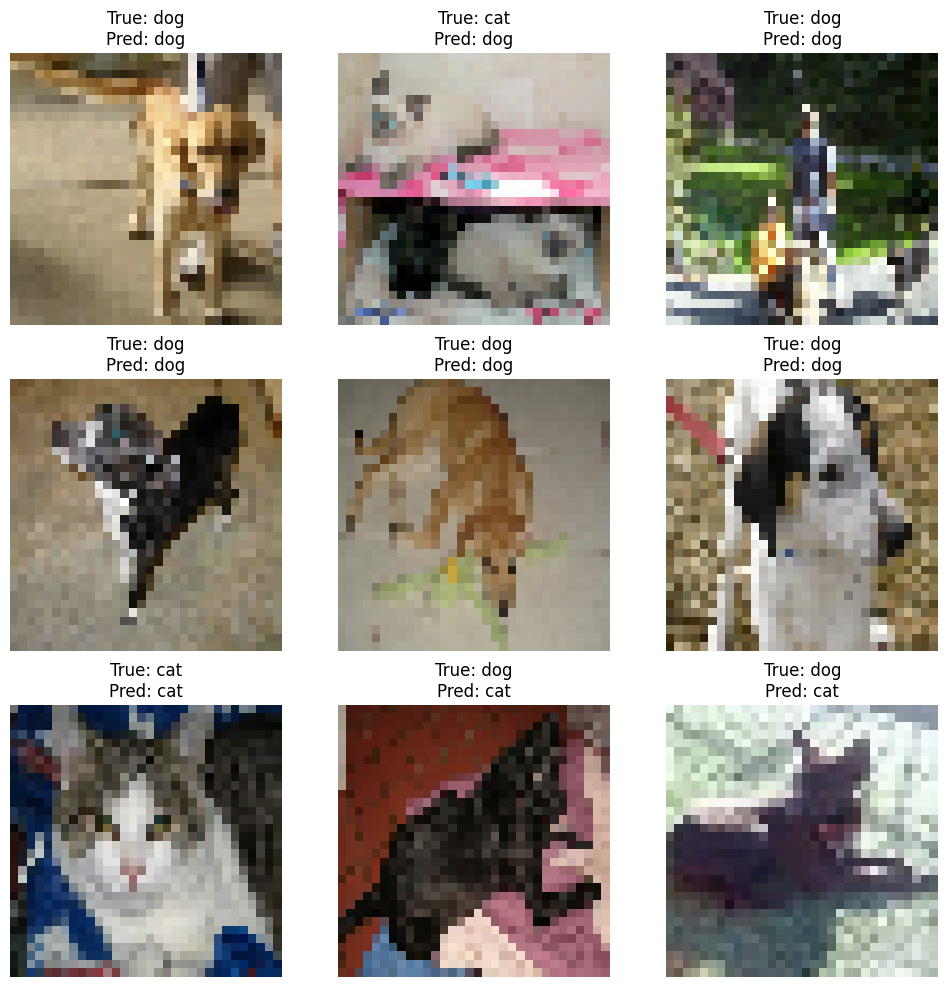

In [16]:
plt.figure(figsize=(12,12))

for images, labels in test_ds.take(1):
    predictions = model.predict(images[:9])

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())

        pred_label = 1 if predictions[i][0] > 0.5 else 0
        true_label = int(labels[i].numpy())

        plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}")
        plt.axis("off")

plt.show()

## **PART 2**

Filtrų masyvo forma: (3, 3, 3, 32)
Bias masyvo forma: (32,)


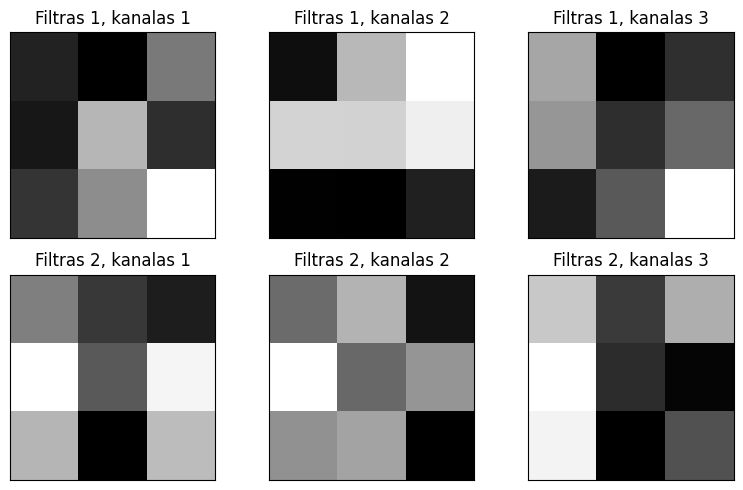

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# paimame pirmo Conv2D sluoksnio svorius
filters, biases = model.layers[0].get_weights()

print("Filtrų masyvo forma:", filters.shape)
print("Bias masyvo forma:", biases.shape)

plt.figure(figsize=(8, 5))
ix = 1

for filter_i in range(2):   # rodome pirmus 2 filtrus
    filter_tmp = filters[:, :, :, filter_i]

    for channel_j in range(3):   # 3 kanalai: R, G, B
        ax = plt.subplot(2, 3, ix)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.imshow(filter_tmp[:, :, channel_j], cmap='gray')
        plt.title(f'Filtras {filter_i+1}, kanalas {channel_j+1}')
        ix += 1

plt.tight_layout()
plt.show()

In [18]:
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.__class__.__name__)

0 conv2d Conv2D
1 max_pooling2d MaxPooling2D
2 conv2d_1 Conv2D
3 max_pooling2d_1 MaxPooling2D
4 conv2d_2 Conv2D
5 flatten Flatten
6 dense Dense
7 dense_1 Dense


In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

model_layers_0 = tf.keras.Model(
    inputs=model.inputs,
    outputs=model.layers[0].output
)

0 conv2d Conv2D
1 max_pooling2d MaxPooling2D
2 conv2d_1 Conv2D
3 max_pooling2d_1 MaxPooling2D
4 conv2d_2 Conv2D
5 flatten Flatten
6 dense Dense
7 dense_1 Dense

Pirmas Conv2D sluoksnis:
Index: 0
Name: conv2d
Filtrų forma: (3, 3, 3, 32)
Bias forma: (32,)


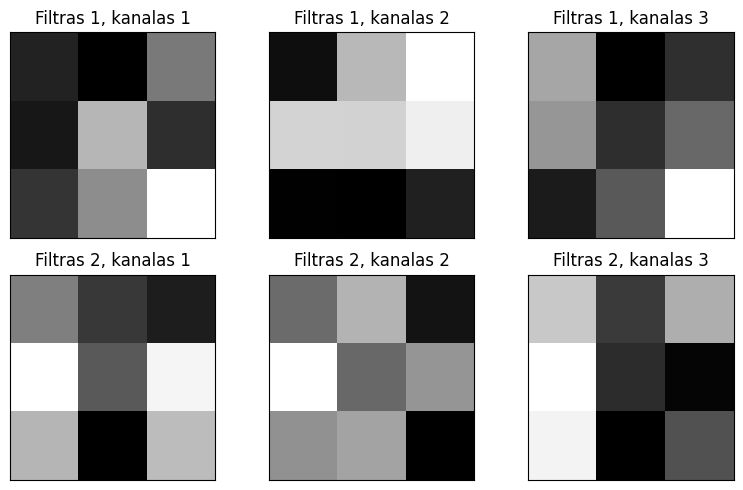

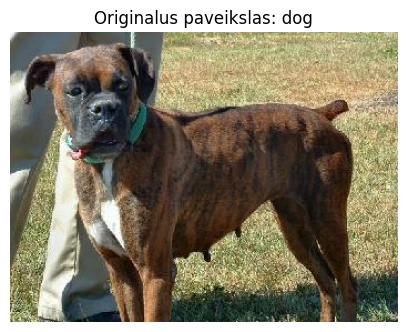

Modelio įėjimo forma: (None, 32, 32, 3)
Paveikslo batch forma: (1, 32, 32, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Feature maps forma: (1, 30, 30, 32)


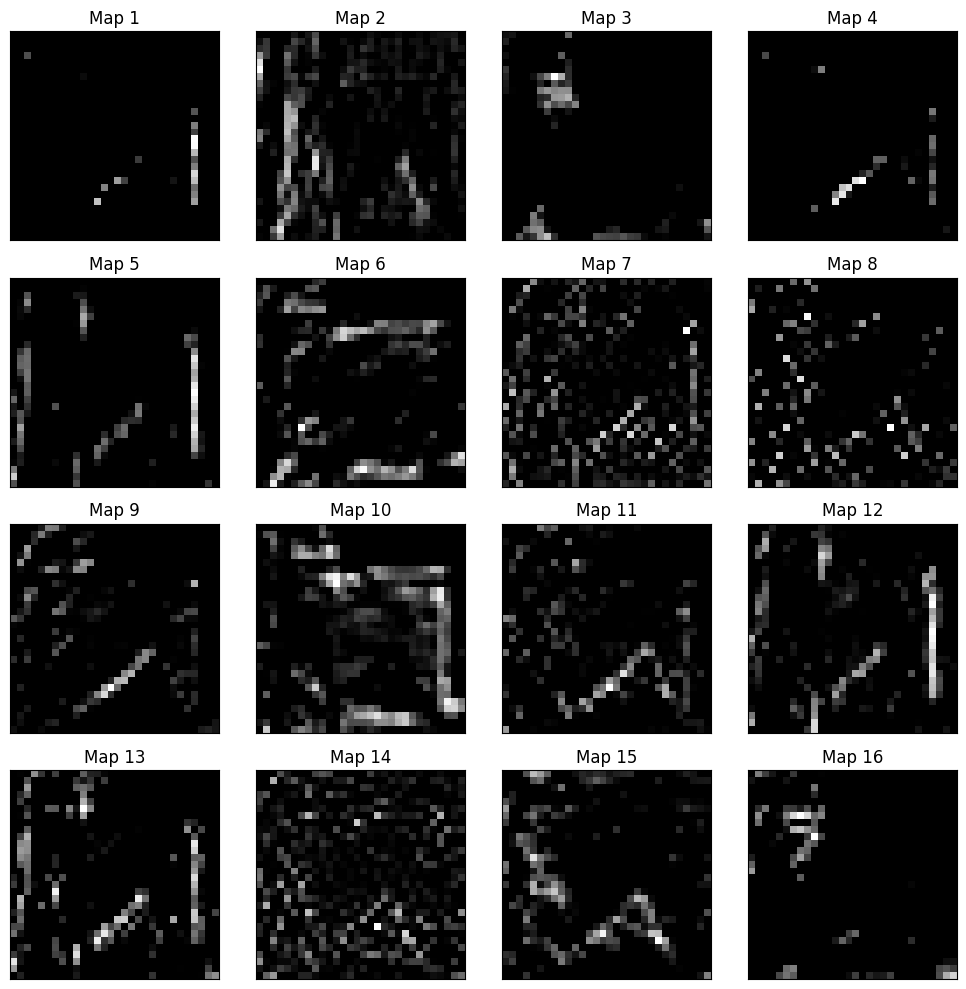

Stipriausias filtras: 31


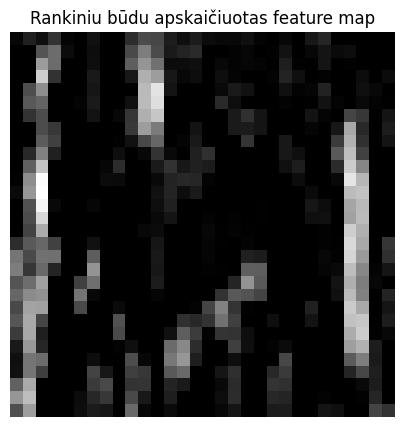

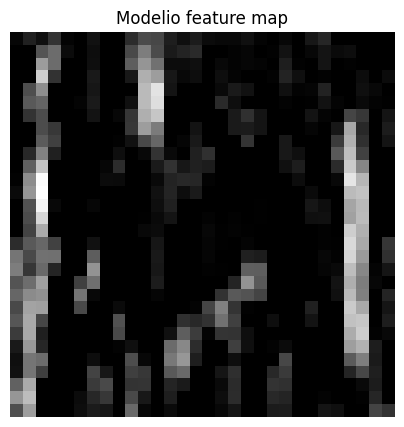

Modelio mean: 0.079417504
Rankinio mean: 0.07941750805618035


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# ===============================================
# 1. Surandame pirmą Conv2D sluoksnį
# ===============================================
conv_layer = None
conv_layer_index = None

for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.__class__.__name__)

    if isinstance(layer, tf.keras.layers.Conv2D) and conv_layer is None:
        conv_layer = layer
        conv_layer_index = i

print("\nPirmas Conv2D sluoksnis:")
print("Index:", conv_layer_index)
print("Name:", conv_layer.name)

# ===============================================
# 2. Paimame filtrus
# ===============================================
filters, biases = conv_layer.get_weights()

print("Filtrų forma:", filters.shape)
print("Bias forma:", biases.shape)

# ===============================================
# 3. Vizualizuojame pirmus 2 filtrus
# ===============================================
plt.figure(figsize=(8,5))
ix = 1

for filter_i in range(2):
    filter_tmp = filters[:, :, :, filter_i]

    for channel_j in range(3):

        ax = plt.subplot(2,3,ix)
        ax.set_xticks([])
        ax.set_yticks([])

        plt.imshow(filter_tmp[:,:,channel_j], cmap='gray')
        plt.title(f'Filtras {filter_i+1}, kanalas {channel_j+1}')

        ix += 1

plt.tight_layout()
plt.show()

# ===============================================
# 4. Paimame vieną paveikslą iš dataset
# ===============================================
for image, label in train_ds_raw.take(1):
    img_original = image.numpy()
    lbl = int(label.numpy())

class_names = ['cat','dog']

plt.figure(figsize=(5,5))
plt.imshow(img_original.astype("uint8"))
plt.title(f"Originalus paveikslas: {class_names[lbl]}")
plt.axis("off")
plt.show()

# ===============================================
# 5. Paruošiame paveikslą modeliui
# ===============================================
input_h = model.input_shape[1]
input_w = model.input_shape[2]

img_resized = tf.image.resize(img_original,(input_h,input_w)).numpy()
img_for_model = img_resized / 255.0

img_batch = np.expand_dims(img_for_model, axis=0)

print("Modelio įėjimo forma:", model.input_shape)
print("Paveikslo batch forma:", img_batch.shape)

# ===============================================
# 6. Sukuriame feature map modelį
# ===============================================
feature_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=conv_layer.output
)

feature_maps = feature_model.predict(img_batch)

print("Feature maps forma:", feature_maps.shape)

# ===============================================
# 7. Parodome 16 feature maps
# ===============================================
num_maps = min(16, feature_maps.shape[-1])

plt.figure(figsize=(10,10))
ix = 1

for i in range(num_maps):

    ax = plt.subplot(4,4,ix)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.imshow(feature_maps[0,:,:,i], cmap='gray')
    plt.title(f"Map {i+1}")

    ix += 1

plt.tight_layout()
plt.show()

# ===============================================
# 8. Randame aktyviausią filtrą
# ===============================================
best_filter = 0
best_value = -1

for k in range(feature_maps.shape[-1]):

    current_max = feature_maps[0,:,:,k].max()

    if current_max > best_value:
        best_value = current_max
        best_filter = k

filter_index = best_filter

print("Stipriausias filtras:", filter_index)

# ===============================================
# 9. Rankinė konvoliucija
# ===============================================
selected_filter = filters[:,:,:,filter_index]
selected_bias = biases[filter_index]

input_image = img_for_model.astype(np.float32)

feature_map_manual = np.zeros((
    input_image.shape[0]-selected_filter.shape[0]+1,
    input_image.shape[1]-selected_filter.shape[1]+1
))

for i in range(feature_map_manual.shape[0]):
    for j in range(feature_map_manual.shape[1]):

        patch = input_image[
            i:i+selected_filter.shape[0],
            j:j+selected_filter.shape[1],
            :
        ]

        feature_map_manual[i,j] = np.sum(patch * selected_filter) + selected_bias

# ReLU
feature_map_manual[feature_map_manual < 0] = 0

# ===============================================
# 10. Manual feature map
# ===============================================
plt.figure(figsize=(5,5))
plt.imshow(feature_map_manual, cmap='gray')
plt.title("Rankiniu būdu apskaičiuotas feature map")
plt.axis("off")
plt.show()

# ===============================================
# 11. Modelio feature map
# ===============================================
plt.figure(figsize=(5,5))
plt.imshow(feature_maps[0,:,:,filter_index], cmap='gray')
plt.title("Modelio feature map")
plt.axis("off")
plt.show()

# ===============================================
# 12. Palyginimas
# ===============================================
feature_map_model = feature_maps[0,:,:,filter_index]

print("Modelio mean:", feature_map_model.mean())
print("Rankinio mean:", feature_map_manual.mean())